# U-Net Inference for Nephrocyte Segmentation

This notebook applies a trained U-Net model to segment nephrocyte images.

**Output Classes:**
- **Background (0)**: Black
- **Slit Membrane (1)**: Red
- **Clusters (2)**: Green

**Mask Output Format:**
- Masks are saved as 2-channel TIF files compatible with Fiji/ImageJ
- Channel 1: Slit membrane (binary, 0 or 255)
- Channel 2: Clusters (binary, 0 or 255)
- Both channels use value 255 for detected pixels
- Fiji will recognize these as separate channels automatically

**Overlay Output Format:**
- Overlays are saved as 3-channel TIF files compatible with Fiji/ImageJ
- Channel 1: Original grayscale image
- Channel 2: Membrane mask (binary, 0 or 255)
- Channel 3: Clusters mask (binary, 0 or 255)
- Fiji can display these as composite images with different colors per channel

In [13]:
"""
Cell 1: Imports and Setup
"""
import os
import warnings
from pathlib import Path
from typing import Tuple, List, Dict, Optional
from datetime import datetime

import time
import numpy as np
import matplotlib.pyplot as plt

# Suppress tifffile warnings about non-standard TIFF tags
warnings.filterwarnings('ignore', message='.*read_bytes.*')
warnings.filterwarnings('ignore', module='tifffile')

from tifffile import imread, imwrite

import torch
import torch.nn as nn
import torch.nn.functional as F

print("Imports completed successfully")
print(f"PyTorch version: {torch.__version__}")

Imports completed successfully
PyTorch version: 2.5.1


In [14]:
"""
Cell 2: Device Configuration
"""

def get_device() -> torch.device:
    """
    Detect and configure the best available device.
    Priority: MPS (Apple Silicon) > CUDA > CPU
    """
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using MPS (Apple Silicon GPU)")
        print(f"MPS built: {torch.backends.mps.is_built()}")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("Using CPU (no GPU acceleration available)")
    
    return device

DEVICE = get_device()
print(f"\nDevice selected: {DEVICE}")

Using MPS (Apple Silicon GPU)
MPS built: True

Device selected: mps


In [15]:
"""
Cell 3: User Configuration - MODIFY THESE PATHS
"""

# =============================================================================
# INPUT/OUTPUT PATHS - MODIFY THESE
# =============================================================================

# Path to the folder containing images to segment
INPUT_FOLDER = Path("/Users/pavel/Downloads/rois_cut_out")

# Path to save segmentation results
OUTPUT_FOLDER = Path("/Users/pavel/Downloads/rois_cut_out_results")

# Path to the trained model file (.pth)
MODEL_PATH = Path("/Users/pavel/Downloads/nephrocytes_stuff/056_v8.pth")

# =============================================================================
# OUTPUT OPTIONS
# =============================================================================

# Save segmentation masks as TIFF files
SAVE_MASKS = True

# Save colored overlay images (PNG)
SAVE_OVERLAYS = True

# Show preview of results (first N images)
SHOW_PREVIEW = True
PREVIEW_COUNT = 3

# =============================================================================
# Validate paths
# =============================================================================

print("Configuration:")
print("="*60)
print(f"Input folder:  {INPUT_FOLDER}")
print(f"Output folder: {OUTPUT_FOLDER}")
print(f"Model path:    {MODEL_PATH}")
print("="*60)

# Check if paths exist
if not INPUT_FOLDER.exists():
    print(f"\n⚠️ WARNING: Input folder does not exist: {INPUT_FOLDER}")
else:
    # Count images
    image_files = list(INPUT_FOLDER.glob("*.tif")) + list(INPUT_FOLDER.glob("*.tiff"))
    image_files = [f for f in image_files if not f.name.startswith('._')]
    print(f"\nFound {len(image_files)} image(s) in input folder")

if not MODEL_PATH.exists():
    print(f"\n⚠️ WARNING: Model file does not exist: {MODEL_PATH}")
else:
    print(f"Model file found: {MODEL_PATH.name}")

# Create output folder
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
print(f"Output folder ready: {OUTPUT_FOLDER}")

Configuration:
Input folder:  /Users/pavel/Downloads/rois_cut_out
Output folder: /Users/pavel/Downloads/rois_cut_out_results
Model path:    /Users/pavel/Downloads/nephrocytes_stuff/056_v8.pth

Found 26 image(s) in input folder
Model file found: 056_v8.pth
Output folder ready: /Users/pavel/Downloads/rois_cut_out_results


In [16]:
"""
Cell 4: U-Net Model Definition
Same architecture as used during training.
"""

class ConvBlock(nn.Module):
    """Double convolution block: Conv -> BN -> ReLU -> Conv -> BN -> ReLU"""
    def __init__(
        self, 
        in_channels: int, 
        out_channels: int, 
        use_batch_norm: bool = True,
        dropout_rate: float = 0.0
    ):
        super().__init__()
        
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not use_batch_norm),
        ]
        if use_batch_norm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
        
        layers.append(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=not use_batch_norm)
        )
        if use_batch_norm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
        
        if dropout_rate > 0:
            layers.append(nn.Dropout2d(dropout_rate))
        
        self.block = nn.Sequential(*layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class EncoderBlock(nn.Module):
    """Encoder block: ConvBlock -> MaxPool"""
    def __init__(
        self, 
        in_channels: int, 
        out_channels: int,
        use_batch_norm: bool = True,
        dropout_rate: float = 0.0
    ):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels, use_batch_norm, dropout_rate)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        skip = self.conv(x)
        pooled = self.pool(skip)
        return pooled, skip


class DecoderBlock(nn.Module):
    """Decoder block: Upsample -> Concat skip -> ConvBlock"""
    def __init__(
        self, 
        in_channels: int, 
        skip_channels: int,
        out_channels: int,
        use_batch_norm: bool = True,
        dropout_rate: float = 0.0
    ):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(
            in_channels, in_channels // 2, 
            kernel_size=2, stride=2
        )
        self.conv = ConvBlock(
            in_channels // 2 + skip_channels, 
            out_channels, 
            use_batch_norm, 
            dropout_rate
        )
    
    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.upsample(x)
        
        diff_h = skip.size(2) - x.size(2)
        diff_w = skip.size(3) - x.size(3)
        x = F.pad(x, [diff_w // 2, diff_w - diff_w // 2,
                      diff_h // 2, diff_h - diff_h // 2])
        
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """U-Net architecture for semantic segmentation."""
    
    def __init__(
        self,
        in_channels: int = 1,
        num_classes: int = 3,
        encoder_channels: List[int] = [64, 128, 256, 512],
        bottleneck_channels: int = 1024,
        use_batch_norm: bool = True,
        dropout_rate: float = 0.0
    ):
        super().__init__()
        
        self.in_channels = in_channels
        self.num_classes = num_classes
        
        # Encoder
        self.encoders = nn.ModuleList()
        ch_in = in_channels
        for ch_out in encoder_channels:
            self.encoders.append(
                EncoderBlock(ch_in, ch_out, use_batch_norm, dropout_rate)
            )
            ch_in = ch_out
        
        # Bottleneck
        self.bottleneck = ConvBlock(
            encoder_channels[-1], bottleneck_channels, 
            use_batch_norm, dropout_rate
        )
        
        # Decoder
        self.decoders = nn.ModuleList()
        decoder_channels = encoder_channels[::-1]
        ch_in = bottleneck_channels
        for i, ch_out in enumerate(decoder_channels):
            skip_ch = decoder_channels[i]
            self.decoders.append(
                DecoderBlock(ch_in, skip_ch, ch_out, use_batch_norm, dropout_rate)
            )
            ch_in = ch_out
        
        # Output
        self.output = nn.Conv2d(encoder_channels[0], num_classes, kernel_size=1)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder path
        skips = []
        for encoder in self.encoders:
            x, skip = encoder(x)
            skips.append(skip)
        
        # Bottleneck
        x = self.bottleneck(x)
        
        # Decoder path
        skips = skips[::-1]
        for decoder, skip in zip(self.decoders, skips):
            x = decoder(x, skip)
        
        return self.output(x)


print("U-Net model definition loaded")

U-Net model definition loaded


In [17]:
"""
Cell 5: Load Model
"""

def load_model(model_path: Path, device: torch.device) -> nn.Module:
    """
    Load trained U-Net model from checkpoint.
    """
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    
    # Get model config from checkpoint
    config = checkpoint.get('config', {})
    
    # Create model with saved config
    model = UNet(
        in_channels=1,
        num_classes=config.get('num_classes', 3),
        encoder_channels=config.get('encoder_channels', [64, 128, 256, 512]),
        bottleneck_channels=config.get('bottleneck_channels', 1024),
        use_batch_norm=config.get('use_batch_norm', True),
        dropout_rate=config.get('dropout_rate', 0.0)
    )
    
    # Load weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    print(f"Model loaded from: {model_path.name}")
    print(f"Trained epoch: {checkpoint.get('epoch', 'N/A')}")
    print(f"Test loss: {checkpoint.get('test_loss', 'N/A'):.6f}" if checkpoint.get('test_loss') else "Test loss: N/A")
    print(f"Model config: {config}")
    
    return model


# Load the model
model = load_model(MODEL_PATH, DEVICE)

Model loaded from: 056_v8.pth
Trained epoch: 71
Test loss: 0.274161
Model config: {'num_classes': 3, 'encoder_channels': [64, 128, 256, 512], 'bottleneck_channels': 1024, 'use_batch_norm': True, 'dropout_rate': 0.05}


In [18]:
"""
Cell 5b: Verify GPU setup before inference
"""
print("="*60)
print("GPU VERIFICATION")
print("="*60)
print(f"Model device: {next(model.parameters()).device}")
print(f"Expected device: {DEVICE}")
print(f"Model dtype: {next(model.parameters()).dtype}")
print("="*60)

GPU VERIFICATION
Model device: mps:0
Expected device: mps
Model dtype: torch.float32


In [19]:
"""
Cell 6: Image Bit-Depth Conversion

Ensures all images are converted to 8-bit before segmentation.
- 8-bit images (uint8): used as-is
- 16-bit images (uint16): converted to 8-bit using contrast stretching
- Other formats: converted appropriately
"""

def ensure_8bit(image: np.ndarray) -> np.ndarray:
    """
    Convert image to 8-bit (uint8) if necessary.
    
    Args:
        image: Input image array (can be 8-bit, 16-bit, or float)
    
    Returns:
        8-bit image (uint8)
    """
    if image.dtype == np.uint8:
        # Already 8-bit, return as-is
        print(f"    Image is already 8-bit (uint8)")
        return image
    
    elif image.dtype == np.uint16:
        # 16-bit to 8-bit conversion using contrast stretching/normalization
        # Formula: (pixel - min) / (max - min) * 255
        img_min, img_max = image.min(), image.max()
        if img_max > img_min:
            image_8bit = ((image.astype(np.float32) - img_min) / (img_max - img_min) * 255).astype(np.uint8)
        else:
            image_8bit = np.zeros_like(image, dtype=np.uint8)
        print(f"    Converted from 16-bit to 8-bit (contrast stretch: {img_min}-{img_max} -> 0-255)")
        return image_8bit
    
    elif image.dtype in [np.float32, np.float64]:
        # Float image - assume range 0-1 or 0-255
        if image.max() <= 1.0:
            image_8bit = (image * 255).astype(np.uint8)
            print(f"    Converted from float [0-1] to 8-bit")
        else:
            image_8bit = np.clip(image, 0, 255).astype(np.uint8)
            print(f"    Converted from float to 8-bit (clipped to 0-255)")
        return image_8bit
    
    else:
        # Other dtypes - use contrast stretching
        print(f"    Warning: Unexpected dtype {image.dtype}, converting to 8-bit")
        img_min, img_max = image.min(), image.max()
        if img_max > img_min:
            image_normalized = (image.astype(np.float32) - img_min) / (img_max - img_min)
            image_8bit = (image_normalized * 255).astype(np.uint8)
        else:
            image_8bit = np.zeros_like(image, dtype=np.uint8)
        return image_8bit


print("Image bit-depth conversion function defined")

Image bit-depth conversion function defined


In [20]:
"""
Cell 7: Inference Functions
"""

def pad_image(image: np.ndarray, multiple: int = 16) -> Tuple[np.ndarray, Tuple[int, int, int, int]]:
    """
    Pad image so dimensions are divisible by `multiple`.
    Returns padded image and padding amounts.
    """
    h, w = image.shape[:2]
    
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple
    
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    
    padding = (pad_top, pad_bottom, pad_left, pad_right)
    
    if any(p > 0 for p in padding):
        image = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='reflect')
    
    return image, padding


def unpad_image(image: np.ndarray, padding: Tuple[int, int, int, int]) -> np.ndarray:
    """
    Remove padding from image.
    """
    pad_top, pad_bottom, pad_left, pad_right = padding
    
    h, w = image.shape[:2]
    
    # Handle zero padding case
    end_h = h - pad_bottom if pad_bottom > 0 else h
    end_w = w - pad_right if pad_right > 0 else w
    
    return image[pad_top:end_h, pad_left:end_w]


def segment_image(
    model: nn.Module,
    image: np.ndarray,
    device: torch.device
) -> np.ndarray:
    """Run segmentation with proper GPU memory cleanup and timing."""
    orig_shape = image.shape
    
    t0 = time.time()
    # Normalize to [0, 1]
    if image.dtype == np.uint8:
        image = image.astype(np.float32) / 255.0
    
    # Pad image
    padded_image, padding = pad_image(image, multiple=16)
    t1 = time.time()
    
    # Convert to tensor: (1, 1, H, W)
    tensor = torch.from_numpy(padded_image).unsqueeze(0).unsqueeze(0).float().to(device)
    t2 = time.time()
    
    # Run inference
    with torch.no_grad():  # Don't track gradients - saves memory
        output = model(tensor)
        # Get predictions immediately and move to CPU
        pred = output.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    
    t3 = time.time()
    
    # CRITICAL: Explicitly delete GPU tensors
    del tensor, output
    
    # Clear MPS cache
    if device.type == 'mps':
        torch.mps.empty_cache()
    
    t4 = time.time()
    
    # Remove padding
    pred = unpad_image(pred, padding)
    t5 = time.time()
    
    print(f"    Preprocessing: {(t1-t0)*1000:.1f}ms")
    print(f"    To device: {(t2-t1)*1000:.1f}ms")
    print(f"    Inference+copy: {(t3-t2)*1000:.1f}ms")
    print(f"    Cleanup: {(t4-t3)*1000:.1f}ms")
    print(f"    Postprocessing: {(t5-t4)*1000:.1f}ms")
    print(f"    TOTAL: {(t5-t0)*1000:.1f}ms")
    
    return pred


def create_multichannel_overlay(
    image: np.ndarray,
    mask: np.ndarray
) -> np.ndarray:
    """
    Create 3-channel TIF overlay: original image + membrane + clusters.
    
    Args:
        image: Grayscale image (H, W)
        mask: Segmentation mask with classes 0, 1, 2 (H, W)
    
    Returns:
        3-channel array (3, H, W) with:
        - Channel 0: Original image
        - Channel 1: Membrane mask (binary: 0 or 255)
        - Channel 2: Clusters mask (binary: 0 or 255)
    """
    # Normalize image to uint8 if needed
    if image.dtype != np.uint8:
        if image.max() <= 1.0:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)
    
    # Extract binary masks
    membrane_mask = (mask == 1).astype(np.uint8) * 255
    clusters_mask = (mask == 2).astype(np.uint8) * 255
    
    # Stack as (3, H, W)
    multichannel = np.stack([image, membrane_mask, clusters_mask], axis=0)
    
    return multichannel


print("Inference functions defined with GPU memory management and timing")

Inference functions defined with GPU memory management and timing


In [21]:
"""
Cell 8: Run Inference on All Images
"""

def process_folder(
    model: nn.Module,
    input_folder: Path,
    output_folder: Path,
    device: torch.device,
    save_masks: bool = True,
    save_overlays: bool = True
) -> List[Dict]:
    """
    Process all images in a folder.
    
    Returns:
        List of results with image paths and statistics
    """
    # Find all TIFF images
    image_files = sorted([
        f for f in input_folder.glob("*.tif") 
        if not f.name.startswith('._')
    ] + [
        f for f in input_folder.glob("*.tiff") 
        if not f.name.startswith('._')
    ])
    
    if not image_files:
        print(f"No TIFF images found in {input_folder}")
        return []
    
    print(f"Processing {len(image_files)} images...")
    print("="*60)
    
    # Create output subdirectories
    if save_masks:
        mask_folder = output_folder / "masks"
        mask_folder.mkdir(parents=True, exist_ok=True)
    
    if save_overlays:
        overlay_folder = output_folder / "overlays"
        overlay_folder.mkdir(parents=True, exist_ok=True)
    
    results = []
    
    for i, img_path in enumerate(image_files):
        print(f"[{i+1}/{len(image_files)}] {img_path.name}", end=" ... \n")
        
        try:
            # Load image
            image = imread(img_path)

            # Ensure image is 8-bit before segmentation
            image = ensure_8bit(image)

            # Run segmentation
            mask = segment_image(model, image, device)
            
            # Calculate statistics
            unique, counts = np.unique(mask, return_counts=True)
            total_pixels = mask.size
            stats = {
                'background_pct': 0.0,
                'membrane_pct': 0.0,
                'clusters_pct': 0.0
            }
            for val, count in zip(unique, counts):
                pct = (count / total_pixels) * 100
                if val == 0:
                    stats['background_pct'] = pct
                elif val == 1:
                    stats['membrane_pct'] = pct
                elif val == 2:
                    stats['clusters_pct'] = pct
            
            # Save masks as 2-channel TIF (membrane + clusters)
            if save_masks:
                # Create separate binary masks for each class
                membrane_mask = (mask == 1).astype(np.uint8) * 255  # Class 1: Membrane
                clusters_mask = (mask == 2).astype(np.uint8) * 255  # Class 2: Clusters
                
                # Stack as 2-channel image: (2, H, W) for ImageJ/Fiji compatibility
                two_channel_mask = np.stack([membrane_mask, clusters_mask], axis=0)
                
                # Save with ImageJ metadata for proper channel recognition in Fiji
                mask_path = mask_folder / f"{img_path.stem}_mask.tif"
                imwrite(
                    mask_path, 
                    two_channel_mask,
                    imagej=True,
                    metadata={'axes': 'CYX'}  # C=channels, Y=height, X=width
                )
            
            # Save overlay as 3-channel TIF
            if save_overlays:
                multichannel_overlay = create_multichannel_overlay(image, mask)
                overlay_path = overlay_folder / f"{img_path.stem}_overlay.tif"
                imwrite(
                    overlay_path,
                    multichannel_overlay,
                    imagej=True,
                    metadata={'axes': 'CYX'}  # C=channels, Y=height, X=width
                )
            
            result = {
                'image_name': img_path.name,
                'image_path': str(img_path),
                'shape': image.shape,
                **stats
            }
            results.append(result)
            
            print(f"    Membrane: {stats['membrane_pct']:.1f}% | Clusters: {stats['clusters_pct']:.1f}%")
            
        except Exception as e:
            print(f"ERROR: {e}")
            results.append({
                'image_name': img_path.name,
                'error': str(e)
            })
    
    print("="*60)
    print(f"Processed {len(results)} images")
    
    if save_masks:
        print(f"Masks saved to: {mask_folder}")
    if save_overlays:
        print(f"Overlays saved to: {overlay_folder}")
    
    return results


# Run inference
results = process_folder(
    model=model,
    input_folder=INPUT_FOLDER,
    output_folder=OUTPUT_FOLDER,
    device=DEVICE,
    save_masks=SAVE_MASKS,
    save_overlays=SAVE_OVERLAYS
)

Processing 26 images...
[1/26] A15_ROI_0.tif ... 
    Converted from 16-bit to 8-bit (contrast stretch: 0-245 -> 0-255)
    Preprocessing: 0.1ms
    To device: 2.2ms
    Inference+copy: 62.7ms
    Cleanup: 0.2ms
    Postprocessing: 0.0ms
    TOTAL: 65.2ms
    Membrane: 24.4% | Clusters: 0.0%
[2/26] A15_ROI_1.tif ... 
    Converted from 16-bit to 8-bit (contrast stretch: 0-149 -> 0-255)
    Preprocessing: 0.1ms
    To device: 0.2ms
    Inference+copy: 42.2ms
    Cleanup: 0.0ms
    Postprocessing: 0.0ms
    TOTAL: 42.6ms
    Membrane: 24.3% | Clusters: 0.0%
[3/26] A15_ROI_2.tif ... 
    Converted from 16-bit to 8-bit (contrast stretch: 0-255 -> 0-255)
    Preprocessing: 0.1ms
    To device: 0.6ms
    Inference+copy: 42.2ms
    Cleanup: 0.0ms
    Postprocessing: 0.0ms
    TOTAL: 42.9ms
    Membrane: 23.2% | Clusters: 0.0%
[4/26] A15_ROI_3.tif ... 
    Converted from 16-bit to 8-bit (contrast stretch: 0-255 -> 0-255)
    Preprocessing: 0.1ms
    To device: 0.6ms
    Inference+copy: 41.9ms



Showing preview of 3 results:


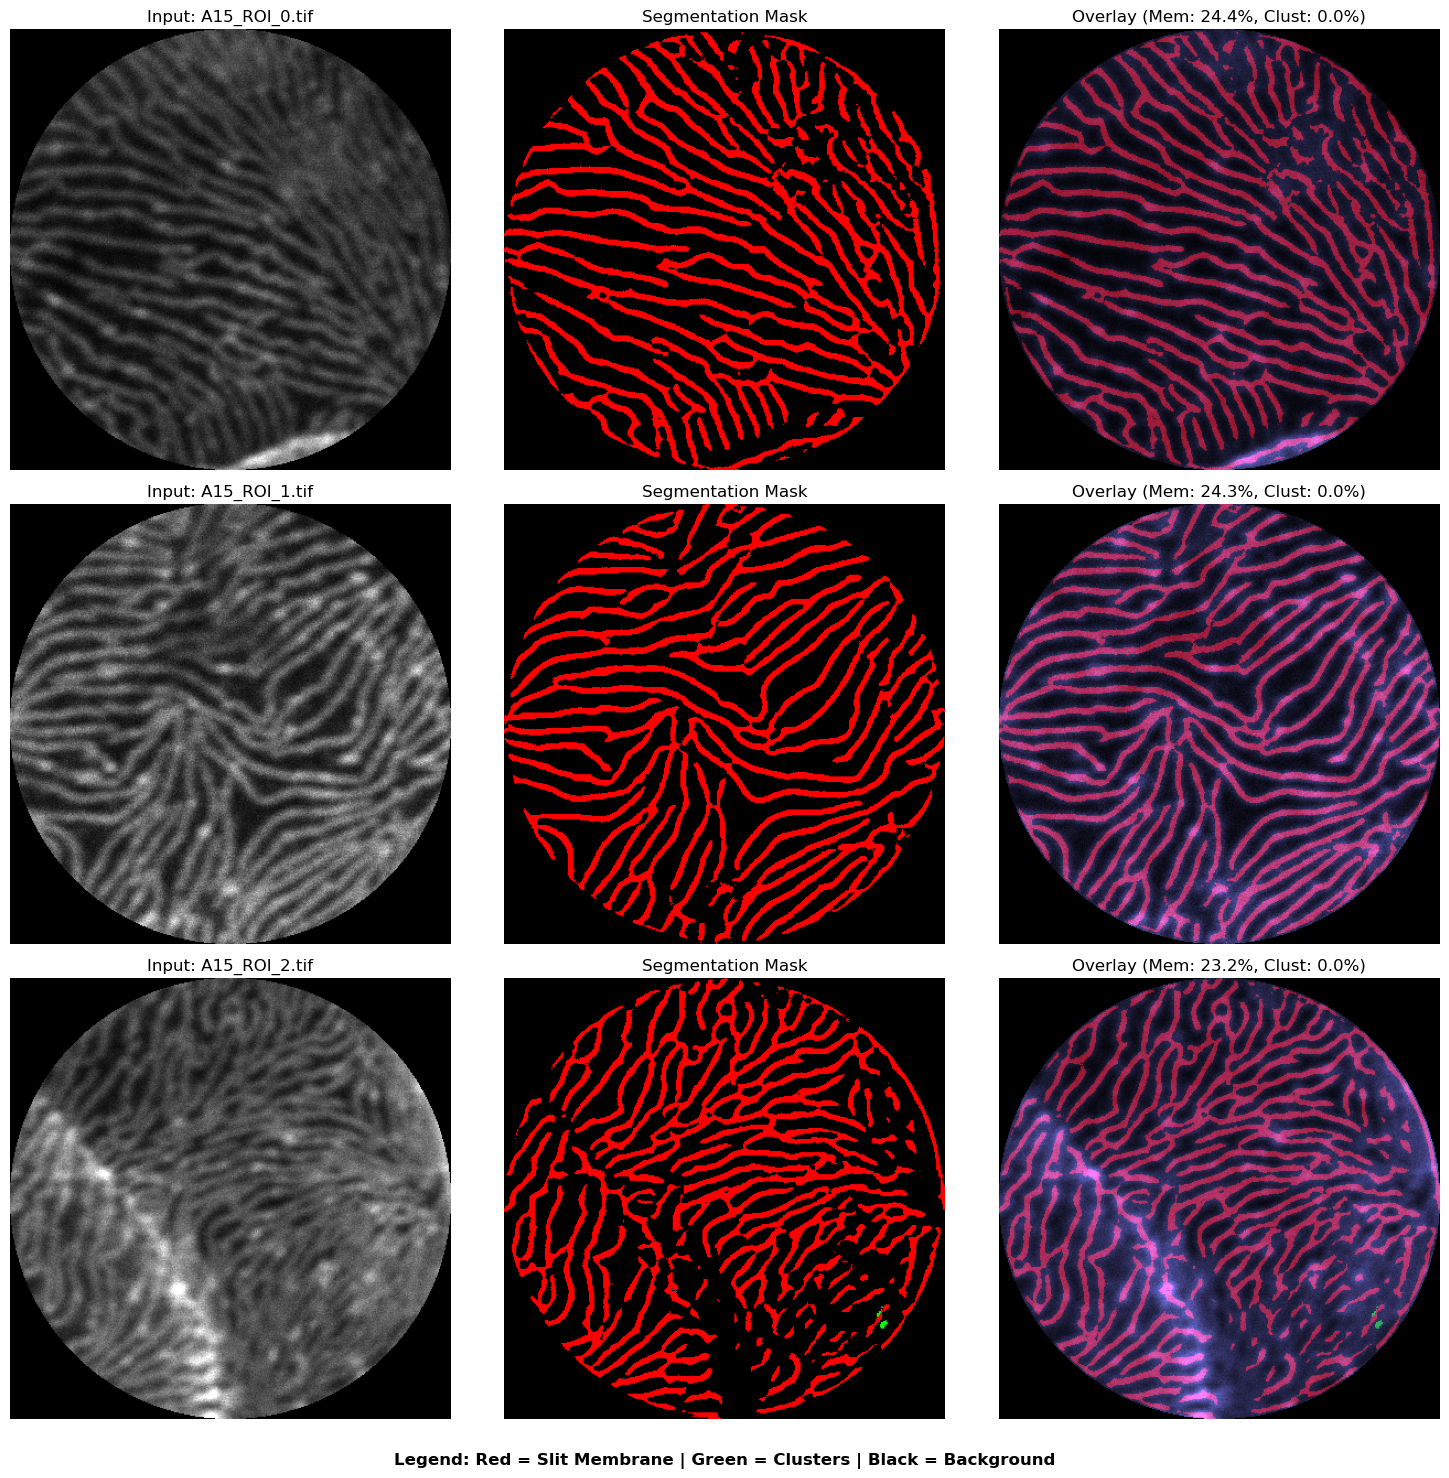

In [22]:
"""
Cell 9: Visualize Results
"""

def visualize_results(
    input_folder: Path,
    output_folder: Path,
    results: List[Dict],
    num_samples: int = 3
):
    """
    Display sample results with input, mask, and overlay.
    """
    # Filter out any errors
    valid_results = [r for r in results if 'error' not in r]
    
    if not valid_results:
        print("No valid results to display")
        return
    
    num_samples = min(num_samples, len(valid_results))
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    mask_folder = output_folder / "masks"
    overlay_folder = output_folder / "overlays"
    
    for i, result in enumerate(valid_results[:num_samples]):
        img_name = result['image_name']
        stem = Path(img_name).stem
        
        # Load original image
        img_path = Path(result['image_path'])
        image = imread(img_path)
        
        # Load mask
        mask_path = mask_folder / f"{stem}_mask.tif"
        if mask_path.exists():
            two_channel_mask = imread(mask_path)
            # Convert from 2-channel (membrane, clusters) to class labels
            # Shape should be (2, H, W) with values 0 or 255
            if two_channel_mask.ndim == 3 and two_channel_mask.shape[0] == 2:
                membrane_channel = two_channel_mask[0] > 0
                clusters_channel = two_channel_mask[1] > 0
                # Reconstruct class labels: 0=background, 1=membrane, 2=clusters
                mask = np.zeros(membrane_channel.shape, dtype=np.uint8)
                mask[membrane_channel] = 1
                mask[clusters_channel] = 2
            else:
                # Fallback for old single-channel format
                mask = two_channel_mask
        else:
            mask = np.zeros_like(image)
        
        # Create colored mask
        colors = np.array([
            [0, 0, 0],       # Background: black
            [255, 0, 0],     # Membrane: red
            [0, 255, 0],     # Clusters: green
        ], dtype=np.uint8)
        mask_colored = colors[np.clip(mask, 0, 2)]
        
        # Load or create overlay
        overlay_path = overlay_folder / f"{stem}_overlay.tif"
        if overlay_path.exists():
            # Load 3-channel TIF overlay
            multichannel = imread(overlay_path)
            # Create RGB composite for display
            # Channel 0: grayscale image (use for all RGB channels)
            # Channel 1: membrane mask (add to red channel)
            # Channel 2: clusters mask (add to green channel)
            if multichannel.ndim == 3 and multichannel.shape[0] == 3:
                base_image = multichannel[0]
                membrane = multichannel[1]
                clusters = multichannel[2]
                # Create RGB overlay
                overlay_rgb = np.stack([base_image, base_image, base_image], axis=-1)
                # Blend membrane (red) and clusters (green) with 50% opacity
                alpha = 0.5
                overlay_rgb[:, :, 0] = np.clip(overlay_rgb[:, :, 0] * (1-alpha) + membrane * alpha, 0, 255).astype(np.uint8)
                overlay_rgb[:, :, 1] = np.clip(overlay_rgb[:, :, 1] * (1-alpha) + clusters * alpha, 0, 255).astype(np.uint8)
                overlay = overlay_rgb
            else:
                # Fallback
                overlay = multichannel
        else:
            # Create overlay from image and mask if file doesn't exist
            multichannel = create_multichannel_overlay(image, mask)
            base_image = multichannel[0]
            membrane = multichannel[1]
            clusters = multichannel[2]
            overlay_rgb = np.stack([base_image, base_image, base_image], axis=-1)
            alpha = 0.5
            overlay_rgb[:, :, 0] = np.clip(overlay_rgb[:, :, 0] * (1-alpha) + membrane * alpha, 0, 255).astype(np.uint8)
            overlay_rgb[:, :, 1] = np.clip(overlay_rgb[:, :, 1] * (1-alpha) + clusters * alpha, 0, 255).astype(np.uint8)
            overlay = overlay_rgb
        
        # Plot
        axes[i, 0].imshow(image, cmap='gray')
        axes[i, 0].set_title(f'Input: {img_name}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask_colored)
        axes[i, 1].set_title(f'Segmentation Mask')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(f'Overlay (Mem: {result["membrane_pct"]:.1f}%, Clust: {result["clusters_pct"]:.1f}%)')
        axes[i, 2].axis('off')
    
    # Add legend
    fig.text(0.5, 0.02, 'Legend: Red = Slit Membrane | Green = Clusters | Black = Background', 
             ha='center', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.05)
    plt.show()


if SHOW_PREVIEW and results:
    print(f"\nShowing preview of {min(PREVIEW_COUNT, len(results))} results:")
    visualize_results(INPUT_FOLDER, OUTPUT_FOLDER, results, num_samples=PREVIEW_COUNT)

In [23]:
"""
Cell 10: Summary Statistics
"""

def print_summary(results: List[Dict]):
    """
    Print summary statistics for all processed images.
    """
    valid_results = [r for r in results if 'error' not in r]
    error_results = [r for r in results if 'error' in r]
    
    print("\n" + "="*70)
    print("INFERENCE SUMMARY")
    print("="*70)
    
    print(f"\nTotal images processed: {len(results)}")
    print(f"Successful: {len(valid_results)}")
    print(f"Errors: {len(error_results)}")
    
    if error_results:
        print("\nImages with errors:")
        for r in error_results:
            print(f"  - {r['image_name']}: {r['error']}")
    
    if valid_results:
        # Calculate aggregate statistics
        membrane_pcts = [r['membrane_pct'] for r in valid_results]
        clusters_pcts = [r['clusters_pct'] for r in valid_results]
        
        print("\nSegmentation Statistics:")
        print("-"*40)
        print(f"Membrane coverage:")
        print(f"  Mean:   {np.mean(membrane_pcts):.2f}%")
        print(f"  Median: {np.median(membrane_pcts):.2f}%")
        print(f"  Min:    {np.min(membrane_pcts):.2f}%")
        print(f"  Max:    {np.max(membrane_pcts):.2f}%")
        
        print(f"\nCluster coverage:")
        print(f"  Mean:   {np.mean(clusters_pcts):.2f}%")
        print(f"  Median: {np.median(clusters_pcts):.2f}%")
        print(f"  Min:    {np.min(clusters_pcts):.2f}%")
        print(f"  Max:    {np.max(clusters_pcts):.2f}%")
        
        # Per-image breakdown
        print("\n" + "-"*40)
        print("Per-Image Results:")
        print("-"*40)
        print(f"{'Image':<40} {'Membrane':>10} {'Clusters':>10}")
        print("-"*60)
        for r in valid_results:
            name = r['image_name'][:38] + ".." if len(r['image_name']) > 40 else r['image_name']
            print(f"{name:<40} {r['membrane_pct']:>9.2f}% {r['clusters_pct']:>9.2f}%")
    
    print("\n" + "="*70)
    print(f"Output location: {OUTPUT_FOLDER}")
    print("="*70)


print_summary(results)


INFERENCE SUMMARY

Total images processed: 26
Successful: 26
Errors: 0

Segmentation Statistics:
----------------------------------------
Membrane coverage:
  Mean:   16.09%
  Median: 20.21%
  Min:    1.13%
  Max:    27.60%

Cluster coverage:
  Mean:   1.91%
  Median: 0.02%
  Min:    0.00%
  Max:    12.13%

----------------------------------------
Per-Image Results:
----------------------------------------
Image                                      Membrane   Clusters
------------------------------------------------------------
A15_ROI_0.tif                                24.39%      0.00%
A15_ROI_1.tif                                24.31%      0.00%
A15_ROI_2.tif                                23.19%      0.03%
A15_ROI_3.tif                                21.05%      0.00%
A15_ROI_4.tif                                27.02%      0.00%
A15_ROI_5.tif                                14.96%      0.11%
A6_ROI_0.tif                                 23.99%      0.00%
A7_ROI_0.tif            

In [24]:
"""
Cell 11: Verify GPU Setup
"""
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"MPS built: {torch.backends.mps.is_built()}")

# Test it actually works
if torch.backends.mps.is_available():
    device = torch.device("mps")
    x = torch.randn(100, 100).to(device)
    y = torch.randn(100, 100).to(device)
    z = x @ y
    print(f" MPS test successful! Result device: {z.device}")
else:
    print("MPS NOT available - still using CPU!")

PyTorch version: 2.5.1
MPS available: True
MPS built: True
 MPS test successful! Result device: mps:0
